# Functional localizer map prediction: monkey (Fig. 3, Supp. Fig. S1)

Loads the outputs already computed and saved by `predict_localizer_maps_monkey.py`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.image as mpimg
import seaborn as sns
import neuroboros as nb

OUT_ROOT = "/dartfs/rc/lab/H/HaxbyLab/yuqi/monkey_kingdom_data/functional_maps/monkey_pairwise_localizer_prediction"

sids = np.load(f"{OUT_ROOT}/sids.npy")
kind_names = {"allbody_obj": "body_vs_object", "allf_obj": "face_vs_object"}
kinds = list(kind_names.keys())
sids

/dartfs-hpc/rc/home/q/f007d9q/neuroboros/src/neuroboros/io.py:60: UserWarning: DataLad dataset core exists at /dartfs-hpc/rc/home/q/f007d9q/.neuroboros-data/core, but does not have source https://gin.g-node.org/neuroboros/core as a sibling.
  warnings.warn(


array(['Dino', 'Fahra', 'Luce', 'Marcel'], dtype='<U6')

## Fig. 3b: congruent vs. incongruent prediction accuracy (ridge)

Reproduces the exact per-monkey color scheme and swatch-legend layout from the original
notebook's final iteration (`hyperalign_localizer_maps_luce_marcel_rank.ipynb`, cells 13-14):
each monkey gets its own (congruent, incongruent) color pair -- M1 orange/light-orange, M2
blue/light-blue, M3 green/light-green, M4 purple/light-purple -- grouped by contrast (face vs
object, then body vs object), with an M1-M4 swatch legend, matching Fig. 3b exactly.

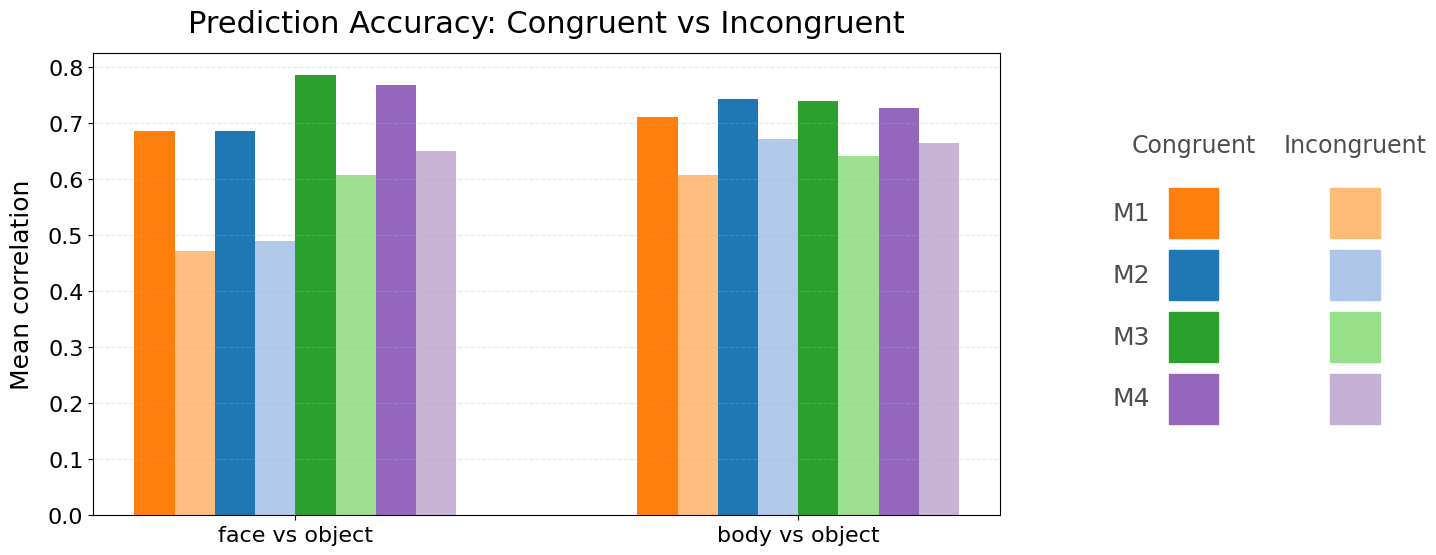

In [2]:
from matplotlib.patches import Rectangle

congruent = np.load(f"{OUT_ROOT}/congruent_ridge.npy")      # (n_sids, n_kinds)
incongruent = np.load(f"{OUT_ROOT}/incongruent_ridge.npy")

subject_colors = {
    "Dino": ("#ff7f0e", "#ffbb78"),
    "Fahra": ("#1f77b4", "#aec7e8"),
    "Luce": ("#2ca02c", "#98df8a"),
    "Marcel": ("#9467bd", "#c5b0d5"),
}
name_map = {"Dino": "M1", "Fahra": "M2", "Luce": "M3", "Marcel": "M4"}
sids_list = list(sids)
categories = ["face vs object", "body vs object"]
category_kind_idx = [kinds.index("allf_obj"), kinds.index("allbody_obj")]

x = np.arange(len(categories))
width = 0.08
offsets = [(i - (len(sids_list) - 1) / 2) * 2 * width for i in range(len(sids_list))]

fig = plt.figure(figsize=(17, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[12, 5], wspace=0.05)
ax = fig.add_subplot(gs[0])
legend_ax = fig.add_subplot(gs[1])
legend_ax.axis("off")

for off, sid in zip(offsets, sids_list):
    i = sids_list.index(sid)
    congr_vals = [congruent[i, k] for k in category_kind_idx]
    incongr_vals = [incongruent[i, k] for k in category_kind_idx]
    ax.bar(x + off - width / 2, congr_vals, width, color=subject_colors[sid][0])
    ax.bar(x + off + width / 2, incongr_vals, width, color=subject_colors[sid][1], alpha=0.95)

ax.set_ylabel("Mean correlation", fontsize=18, labelpad=10)
ax.set_title("Prediction Accuracy: Congruent vs Incongruent", fontsize=22, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=16)
ax.tick_params(axis="y", labelsize=16)
ax.grid(axis="y", linestyle="--", alpha=0.3)

sq = 0.8
n_rows = len(sids_list)
col_x = [0, 2.6]
for row_i, sid in enumerate(sids_list):
    y = n_rows - 1 - row_i
    legend_ax.add_patch(Rectangle((col_x[0], y), sq, sq, color=subject_colors[sid][0]))
    legend_ax.add_patch(Rectangle((col_x[1], y), sq, sq, color=subject_colors[sid][1]))
    legend_ax.text(col_x[0] - 0.3, y + sq / 2, name_map[sid], ha="right", va="center", fontsize=18, color="#4d4d4d")
for cx, label in zip(col_x, ["Congruent", "Incongruent"]):
    legend_ax.text(cx + sq / 2, n_rows + 0.3, label, ha="center", va="bottom", fontsize=17, color="#4d4d4d")
legend_ax.set_xlim(-2.2, col_x[-1] + sq + 0.5)
legend_ax.set_ylim(-0.5, n_rows + 1)
legend_ax.set_aspect("equal")

fig.savefig("monkey_localizer_fig3b_congruent_vs_incongruent.png", dpi=200, bbox_inches="tight")
plt.show()

## Fig. 3a / Supp. Fig. S1: individual measured vs. predicted maps (z-scored, ridge)

Reproduces the exact plotting convention from the final version of the original notebook
(`hyperalign_localizer_maps_luce_marcel_rank.ipynb`): each map is z-scored per-map on a shared
-4 to 4 scale (`vmax=4`), with a hard alpha cutoff below the 95th-percentile `|z|`
(`norm.ppf(0.95)`) so only the top/bottom 5% of vertices are shown at all, using the mako-rocket
diverging colormap. Panels are cropped to the lateral view only, matching the paper figure
(a single brain view per subject, not all three). `align="ridge"`.

In [3]:
from scipy.stats import norm
import io
from PIL import Image

nc = 10
_colors = np.concatenate(
    [sns.color_palette("mako", nc)[1:],
     [[0.9, 0.9, 0.9]],
     sns.color_palette("rocket", nc)[1:][::-1]],
    axis=0)
cmap_zscore = mpl.colors.LinearSegmentedColormap.from_list('mako_rocket', _colors)

mask_mk = nb.mask('lr', 'mkavg-ico32')
actual_ts = np.load(f"{OUT_ROOT}/actual_ts_all_subjects.npy")  # (n_sids, n_kinds, n_verts)
predicted_ts_ridge = np.load(f"{OUT_ROOT}/predicted_ts_ridge.npy")
sids_list = list(sids)
name_map = {"Dino": "M1", "Fahra": "M2", "Luce": "M3", "Marcel": "M4"}

vmax = 4
tail_threshold = norm.ppf(0.95)
LATERAL_CROP_HEIGHT = 530


def zscore_and_alpha(vals):
    z = (vals - np.nanmean(vals)) / np.nanstd(vals)
    result = np.full(len(mask_mk), np.nan)
    result[mask_mk] = z
    alpha = np.abs(result) / vmax
    alpha[np.abs(result) < tail_threshold] = 0.0
    return result, alpha


def lateral_view(im, label, size=130):
    im.img = im.img.crop((0, 0, im.img.size[0], LATERAL_CROP_HEIGHT))
    return im.title(label, size=size)


def contrast_end_labels(contrast_name):
    high_word, low_word = [w.strip().capitalize() for w in contrast_name.split(' vs ')]
    return f"{low_word} > {high_word}", f"{high_word} > {low_word}"


def make_directional_colorbar(vmax, contrast_name, cmap, width_px, dpi=150, end_fontsize=34, height_in=1.4):
    low_label, high_label = contrast_end_labels(contrast_name)
    width_in = width_px / dpi
    fig = plt.figure(figsize=(width_in, height_in), dpi=dpi)
    cb_ax = fig.add_axes([0.15, 0.5, 0.70, 0.20])
    norm_cb = mpl.colors.Normalize(vmin=-vmax, vmax=vmax)
    mpl.colorbar.ColorbarBase(cb_ax, cmap=cmap, norm=norm_cb, orientation='horizontal', ticks=[])
    cb_ax.set_xticks([])
    fig.text(0.15, 0.08, low_label, ha='left', va='bottom', fontsize=end_fontsize, weight='bold')
    fig.text(0.85, 0.08, high_label, ha='right', va='bottom', fontsize=end_fontsize, weight='bold')
    buf = io.BytesIO()
    fig.savefig(buf, format='png', facecolor='white')
    plt.close(fig)
    buf.seek(0)
    return Image.open(buf).convert('RGBA')


def create_subfigure_banner(text, width_px=None, figsize=(22, 1.8), fontsize=48, dpi=300):
    if width_px is not None:
        figsize = (width_px / dpi, figsize[1])
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi, facecolor='white')
    ax.axis('off')
    ax.text(0.5, 0.5, text, fontsize=fontsize, weight='bold', va='center', ha='center')
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
    buf = io.BytesIO()
    fig.savefig(buf, format='png', facecolor='white')
    plt.close(fig)
    buf.seek(0)
    return Image.open(buf).convert('RGBA')

### Fig. 3a: two example monkeys (M3=Luce, M4=Marcel), face vs. object, lateral view

/dartfs-hpc/rc/home/q/f007d9q/neuroboros/src/neuroboros/plot_mebrains.py:258: RuntimeWarning: invalid value encountered in cast
  img = np.round(img * 255.0).astype(np.uint8)


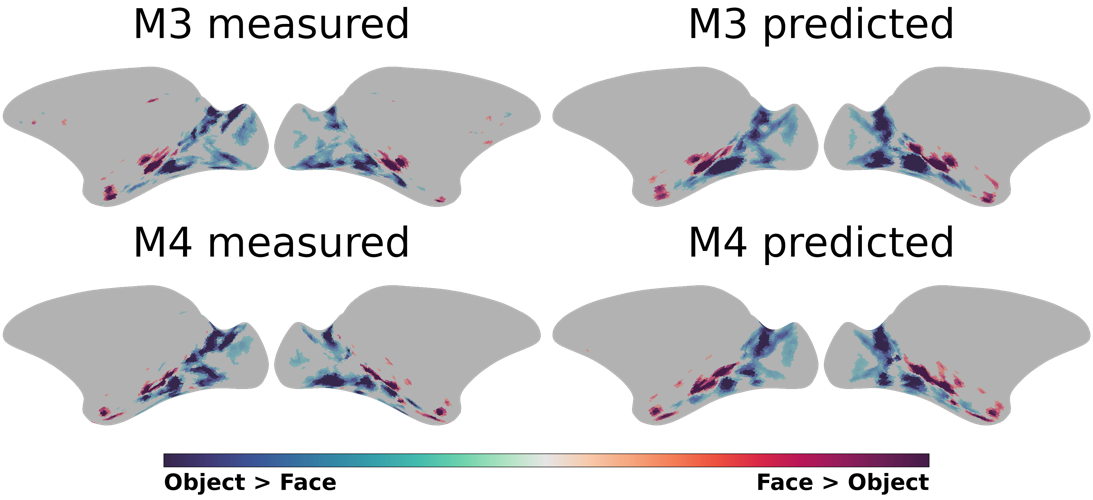

In [4]:
luce_marcel = ["Luce", "Marcel"]
kind_idx = kinds.index("allf_obj")

subject_rows = []
for sid in luce_marcel:
    i = sids_list.index(sid)
    label = name_map[sid]

    z, alpha = zscore_and_alpha(actual_ts[i, kind_idx])
    im_meas = nb.plot_mebrains(z, vmax=vmax, vmin=-vmax, cmap=cmap_zscore, alpha=alpha,
                                title=None, medial_wall_color=[0.7, 0.7, 0.7, 1], colorbar=False)
    im_meas = lateral_view(im_meas, f"{label} measured")

    z, alpha = zscore_and_alpha(predicted_ts_ridge[i, kind_idx])
    im_pred = nb.plot_mebrains(z, vmax=vmax, vmin=-vmax, cmap=cmap_zscore, alpha=alpha,
                                title=None, medial_wall_color=[0.7, 0.7, 0.7, 1], colorbar=False)
    im_pred = lateral_view(im_pred, f"{label} predicted")

    subject_rows.append(nb.Image.hstack([im_meas, im_pred], padding=20))

grid_lm = nb.Image.vstack(subject_rows, padding=30)
cb_lm = make_directional_colorbar(vmax, "face vs object", cmap_zscore, width_px=grid_lm.img.size[0])
panel_fig3a = nb.Image.vstack([grid_lm, cb_lm], padding=20)
panel_fig3a.save("monkey_localizer_fig3a_M3_M4_face_vs_object.png")
panel_fig3a

### Supp. Fig. S1: all four monkeys, both localizer contrasts, lateral view

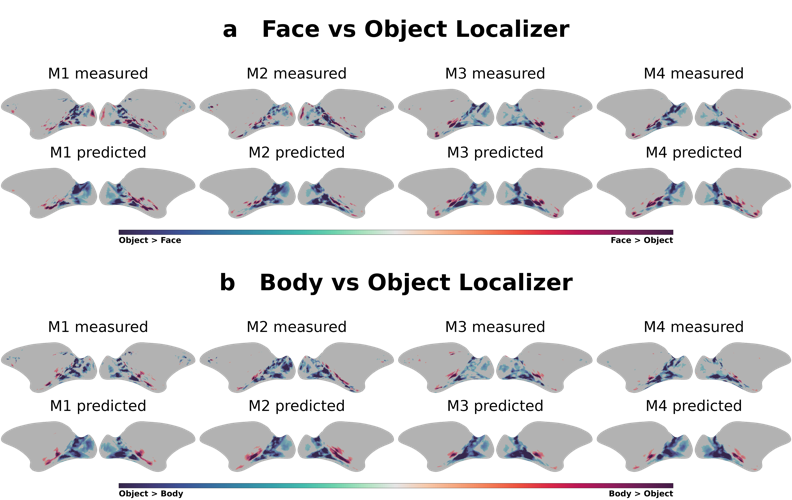

In [5]:
def generate_contrast_grid_lateral(kind_key):
    k_idx = kinds.index(kind_key)
    meas_ims, pred_ims = [], []
    for sid in sids_list:
        i = sids_list.index(sid)
        label = name_map[sid]

        z, alpha = zscore_and_alpha(actual_ts[i, k_idx])
        im_meas = nb.plot_mebrains(z, vmax=vmax, vmin=-vmax, cmap=cmap_zscore, alpha=alpha,
                                    title=None, medial_wall_color=[0.7, 0.7, 0.7, 1], colorbar=False)
        meas_ims.append(lateral_view(im_meas, f"{label} measured"))

        z, alpha = zscore_and_alpha(predicted_ts_ridge[i, k_idx])
        im_pred = nb.plot_mebrains(z, vmax=vmax, vmin=-vmax, cmap=cmap_zscore, alpha=alpha,
                                    title=None, medial_wall_color=[0.7, 0.7, 0.7, 1], colorbar=False)
        pred_ims.append(lateral_view(im_pred, f"{label} predicted"))

    return nb.Image.vstack([
        nb.Image.hstack(meas_ims, padding=20),
        nb.Image.hstack(pred_ims, padding=20),
    ], padding=30)


grid_a = generate_contrast_grid_lateral("allf_obj")
banner_a = create_subfigure_banner("a   Face vs Object Localizer", width_px=grid_a.img.size[0])
cb_a = make_directional_colorbar(vmax, "face vs object", cmap_zscore, width_px=grid_a.img.size[0])
subfigure_a = nb.Image.vstack([banner_a, grid_a, cb_a], padding=30)

grid_b = generate_contrast_grid_lateral("allbody_obj")
banner_b = create_subfigure_banner("b   Body vs Object Localizer", width_px=grid_b.img.size[0])
cb_b = make_directional_colorbar(vmax, "body vs object", cmap_zscore, width_px=grid_b.img.size[0])
subfigure_b = nb.Image.vstack([banner_b, grid_b, cb_b], padding=30)

panel_s1 = nb.Image.vstack([subfigure_a, subfigure_b], padding=60)
panel_s1.save("monkey_localizer_supp_s1_all4_lateral.png")
panel_s1